# Hohmann Transfer Tutorial

The goal of this notebook is to familiarize you with Orekit's python wrapper using a Hohmann transfer as ane example. This tutorial assumes some familiarity with astrodynamics concepts and Orekit as a library. Programmatically, it assumes matplotlib, and orekit have all been installed. However, I won't assume intimate knowledge of Orekit's inner workings and will explain those details as we go.

## Imports

I'm trying to minimize the additional package installations you have to make with this tutorial, so we'll be using math in place of numpy. Because orekit is natively a Java library, you need to run the Java Virtual Machine in order for python to run the underlying Java code. Orekit also requires that you have a library of external data downloaded. Without either of these, you'll get random errors in otherewise functional code. If you already have orekit-data downloaded, you can comment out the download_orekit_data_curdir() lines. 

```Propagator```is the parent class for ```KeplerianPropagator```, and is the top-most interface for all orbit propagation. In this notebook, we'll be using it to keep track of the coordinates our spacecraft follows so that we can plot it at the very end.

```KeplerianOrbit``` is the class we'll use to define the initial orbit of our satellite. You punch in the 6 classical orbital elements and get out an object representing a classic, Keplerian orbit. You will feed this object into the `KeplerianPopagator` class and the newly created propagation object will be what handles moving the spacecraft forward in time.

`PositionAngleType` is pretty self explanatory. There are few measures of your "angle" when travelling on an ellipse (e.g., mean anomaly, true anomaly) that you can pick, and this class is used to specify that when setting up `KeplerianPopagator`.

`FramesFactory` has a silly name bruh. "Factory." This class is like `PositionAngleType` in that it contains a bunch of objects that you can pass into an orbit. We will use this to specify that our ```KeplerianOrbit``` is being measured in an Earth-centered inertial frame.

`LOFType` is like `PositionAngleType`, except it contains various *Local Orbital Frames* that can be tracked from the spacecraft's perspective. These are reference frames centered on the spacecraft whose orbit we're propagating. 

`TimeScalesFactory` is like `FramesFactory`, except for different time scales. We can understand time scales to be the system used to track how we're keeping track of time. Coordinated Universal Time is the time scale used in this script, but there are other options like International Atomic Time, which doesn't take into account leap seconds because it's designed to be a continuous time scale.

`AbsoluteDate` takes a `TimeScalesFactory` object as an argument. You define a date inside of the chosen time scale. When you propagate for X units of time, you have to choose a start date. It matters to take this into account since things like the Earth's gyroscopic precession are time-varying.

I'm not explaining what `Constants` are. Take a wild guess what that could mean.

`KeplerianPropagator` is a child class of `Propagator`. It analytically propagates an orbit, significantly limiting numerical errors propagating and causing drift over time.

`ApsideDetector`, `DateDetector` are self-explanatory. For clarity, apsis is the general term for periapsis and apoapsis (i.e., being the closest and furthest respectively from the primary body in an elliptial orbit). 

`StopOnEvent` is an event handler. Basically, it's what you can tell the propagator to do when it detects an event. In this script, we'll use it to tell our propagator to pause and track its state before propagating to a future time stamp.

`ImpulseManuever` is what applies the burns to your propagation. You pass in when and how big of a $\Delta v$ to fire and you apply the newly created manuever object into your propagator so that your spacecraft knows when to fire and where it will go thereafter.

`LofOffset` acts as an attitude provider for our satellite. In the case of our script, we choose LofOffset to maintain alignment with our local frame. It also accepts an inertial frame from which to compute the spacecraft's alignment vectors.

I'm not explaining what `Vector3D` is. Take a wild guess what that could mean.

`PythonOrekitFixedStepHandler` is the parent class for our step-handling class, ensuring that our python step handler can be successfully passed into the underlying Java code.

In [27]:
import math
import orekit
import matplotlib.pyplot as plt

orekit.initVM()

from orekit.pyhelpers import download_orekit_data_curdir, setup_orekit_curdir

setup_orekit_curdir("/Users/beaveracosta/orekit-data")
# download_orekit_data_curdir()
# setup_orekit_curdir()

from org.orekit.propagation import Propagator
from org.orekit.orbits import KeplerianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory, LOFType
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants
from org.orekit.forces.maneuvers import ImpulseManeuver
from org.orekit.attitudes import LofOffset
from org.orekit.propagation.analytical import KeplerianPropagator
from org.orekit.propagation.events import ApsideDetector, DateDetector
from org.orekit.propagation.events.handlers import StopOnEvent
from org.hipparchus.geometry.euclidean.threed import Vector3D

from org.orekit.propagation.sampling import PythonOrekitFixedStepHandler

# Step Handling

In theory, we could avoid writing up this class entirely if we simply propagated in small time steps with a for loop and then appended the spacecraft's current position to a list in each iteration of the loop. In fact, that's the approach I took in my <a href='https://github.com/GeostationaryBeaver/16.346-Astrodynamics/blob/main/term_project/src/propagate.py'> astrodynamics final project</a>.

```python
N      = 1500
T_span = 6 * 30 * 24 * 3600
times  = np.linspace(0, T_span, N)
for t in times:
    date_t = init_date.shiftedBy(float(t))

    # ── Chief state ──
    chief_state = chief_prop.propagate(date_t)

```
However, this approach needlessly slows down the simulation. Going between Python and Java is the slowest operation our code does, so making tiny propagations in Java and then harvesting that information in Python slows things down significantly. If you instead pass a step handler into your propagation, you let Orekit run its fast Java code without taking constant breaks to give Python bits of information that could instead be supplied all at once.

In [28]:
class TrajectoryCollector(PythonOrekitFixedStepHandler):
    """Samples and stores spacecraft 2D position (in km) at fixed intervals."""
    def __init__(self):
        super().__init__()
        self.x = []
        self.y = []

    def init(self, s0, t, step):
        pass

    def handleStep(self, currentState):
        # Extract inertial position in meters and convert to kilometers
        pos = currentState.getPVCoordinates().getPosition()
        self.x.append(pos.getX() / 1000.0)
        self.y.append(pos.getY() / 1000.0)

    def finish(self, *args):
        pass

# Create the Initial Orbit

Define the constants of the orbit the spacecraft follows before any burns are applied. I assume you know what each classical orbital element is, but the image below provides a refresher. It should be noted that the initial parameters are chosen pretty arbitrarily.

<!-- ![Orbital elements diagram](https://upload.wikimedia.org/wikipedia/commons/thumb/e/eb/Orbit1.svg/960px-Orbit1.svg.png){style='width:50%;'} -->
<div style='background-color:white;width:50%;'>
<img src='https://upload.wikimedia.org/wikipedia/commons/thumb/e/eb/Orbit1.svg/960px-Orbit1.svg.png'>
</div>

In [29]:
# --- System Constants ---
mu = Constants.EIGEN5C_EARTH_MU
earth_radius = Constants.WGS84_EARTH_EQUATORIAL_RADIUS

# --- Define Initial Elliptical Orbit ---
r_perigee = earth_radius + 400e3
r_apogee = earth_radius + 2000e4
a_init = (r_perigee + r_apogee) / 2.0
e_init = (r_apogee - r_perigee) / (r_apogee + r_perigee)
i_init = 0.0
argperi_init = 0.0
raan_init = 0.0
anomaly_init = 0.0

inertial_frame = FramesFactory.getEME2000()
utc = TimeScalesFactory.getUTC()
initial_date = AbsoluteDate(2026, 7, 23, 23, 54, 30.0, utc)

initial_orbit = KeplerianOrbit(a_init, e_init, i_init, argperi_init, raan_init, anomaly_init,
                                PositionAngleType.TRUE, 
                                inertial_frame, initial_date, mu)

print("--- Initial Orbit ---")
print(f"Semi-major axis: {initial_orbit.getA() / 1000:.2f} km")
print(f"Eccentricity:    {initial_orbit.getE():.4f}")

--- Initial Orbit ---
Semi-major axis: 16578.14 km
Eccentricity:    0.5911


# Calculate When Apogee Occurs

We've already covered the overhead of what each class does, so this snippet is fairly self explanatory. The KeplerianPropagator uses analytical methods to propagate the orbit, forgoing the drift inevitably faced by numerical methods like RK4. Keep in mind that `finder_prop` is only supposed to determine when apogee occurs becuase `finder_prop.propagate(...)` returns the state of the spacecraft at the end of the propagation.

In [30]:
finder_prop = KeplerianPropagator(initial_orbit)

# ApsideDetector triggers at perigee and apogee. StopOnEvent halts propagation.
# Since we start at perigee, the first event it hits will be apogee.
apside_detector = ApsideDetector(initial_orbit).withHandler(StopOnEvent())
finder_prop.addEventDetector(apside_detector)

# Propagate forward by one period; it will stop early at apogee
state_at_apogee = finder_prop.propagate(initial_date.shiftedBy(initial_orbit.getKeplerianPeriod()))
t1 = state_at_apogee.getDate()

print(f"\n[Event Detected] Apogee found at: {t1}")


[Event Detected] Apogee found at: 2026-07-24T02:51:31.468645574024321808Z


# Calculate the Maneuvers

Like the initial orbit, we pick our target orbit arbitrarily and analytically derive the necessary $\Delta v$ to raise the perigee and then to circularize the orbit. I won't derive the formulas to calculate said $\Delta v$, but you can find them explained <a hre='$\Delta v$'>here.<a>

In [31]:
r_target = earth_radius + 6000e3
a_transfer = (r_apogee + r_target) / 2.0

# Burn 1 Delta-V (at initial apogee)
v_i1 = math.sqrt(mu * (2.0 / r_apogee - 1.0 / a_init))
v_t1 = math.sqrt(mu * (2.0 / r_apogee - 1.0 / a_transfer))
delta_v1 = v_t1 - v_i1

# Burn 2 Delta-V (at transfer apogee)
v_t2 = math.sqrt(mu * (2.0 / r_target - 1.0 / a_transfer))
v_circ = math.sqrt(mu / r_target)
delta_v2 = v_circ - v_t2

# Time of flight for the transfer orbit (half a period)
transfer_period = 2.0 * math.pi * math.sqrt((a_transfer ** 3) / mu)
t_tof = transfer_period / 2.0
t2 = t1.shiftedBy(t_tof)

print(f"\n[Event Determined] Circularizing burn will occur at: {t2}")


[Event Determined] Circularizing burn will occur at: 2026-07-24T06:35:14.450958874736443226Z


# Create the Propagator

Here we create our main propagator that will run the full simulation, both burns included. After creating the propagator, we create an instance of our `TrajectoryCollector()` to cast into the propagator we've made. Note the dx denoting how often steps are handled. 

The LofOffsets allow us to specify the direction the $\Delta v$ vectors, and the vectors we pass into the `ImpulseManuever` classes.

In [32]:
main_prop = KeplerianPropagator(initial_orbit)

dx = 30.0 #seconds
collector = TrajectoryCollector()
Propagator.cast_(main_prop).setStepHandler(dx, collector)

# Align attitude X-axis with velocity (TNW frame: Tangent, Normal, out-of-plane W)
attitude_provider = LofOffset(inertial_frame, LOFType.TNW)
main_prop.setAttitudeProvider(attitude_provider)

# Define Maneuver 1 (Transfer Injection)
# Vector3D(x, y, z) -> Applying strictly along the Tangent (velocity) axis
dv1_vec = Vector3D(delta_v1, 0.0, 0.0) 
maneuver1 = ImpulseManeuver(DateDetector(t1), attitude_provider, dv1_vec, 300.0)
main_prop.addEventDetector(maneuver1)

# Define Maneuver 2 (Circularization)
dv2_vec = Vector3D(delta_v2, 0.0, 0.0)
maneuver2 = ImpulseManeuver(DateDetector(t2), attitude_provider, dv2_vec, 300.0)
main_prop.addEventDetector(maneuver2)

# Propagate the Orbits

It took a lot of overhead because of how granular Orekit is, but it ends up working out when the time comes to actually propagate since all you have to do is tell `main_prop` how long to propagate for before stopping so that we can record the location of the burns. 

In [33]:
# Get position at Burn 1 (Initial Apogee)
pv_burn1 = main_prop.propagate(t1).getPVCoordinates().getPosition()
x_burn1, y_burn1 = pv_burn1.getX() / 1000.0, pv_burn1.getY() / 1000.0

# Get position at Burn 2 (Transfer Apogee)
final_state = main_prop.propagate(t2)
pv_burn2 = final_state.getPVCoordinates().getPosition()
x_burn2, y_burn2 = pv_burn2.getX() / 1000.0, pv_burn2.getY() / 1000.0

# Get position after circling the Earth once
final_orbit = final_state.getOrbit()
final_period = final_orbit.getKeplerianPeriod()
more_len = main_prop.propagate(t2.shiftedBy(final_period)).getPVCoordinates().getPosition()


# Plotting the Trajectory

The only thing of note here is that this is where we can use our collector object to harvest the x and y coordinates of the spacecraft. Everything else is just matplotlib stuff that can be learned pretty quickly from tons of sources online. Here's the matplotlib site as one <a href='https://matplotlib.org/stable/users/explain/quick_start.html'>possible reference.</a>

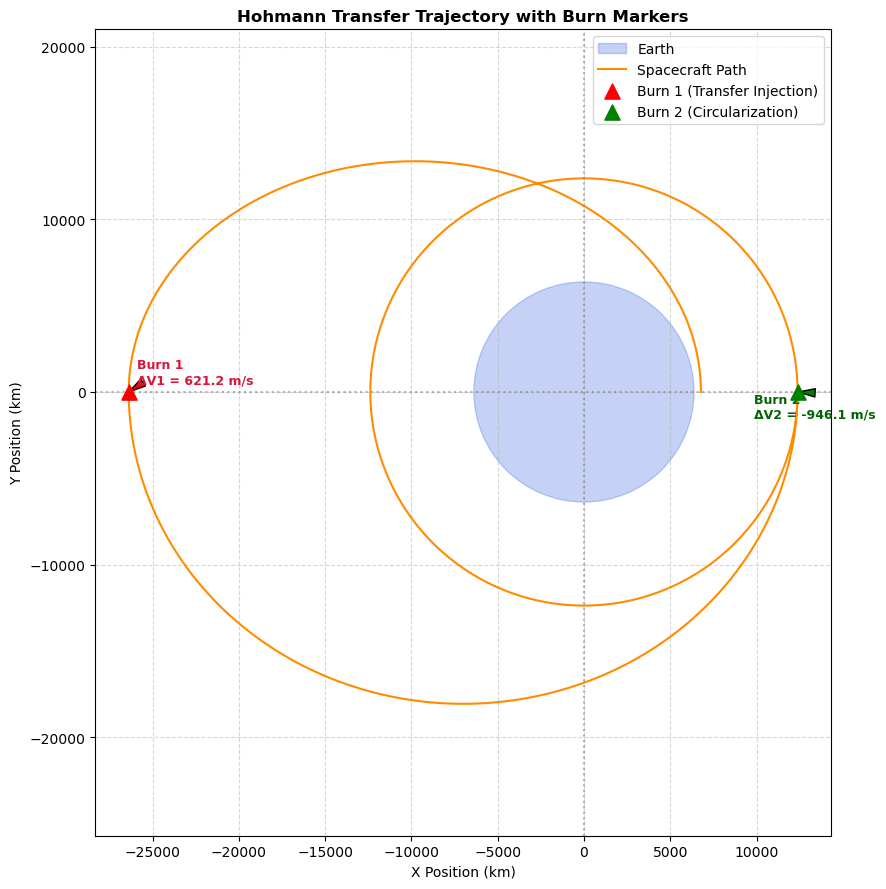

In [34]:
plt.figure(figsize=(9, 9))

# Draw Earth
earth_radius_km = Constants.WGS84_EARTH_EQUATORIAL_RADIUS / 1000.0
earth_circle = plt.Circle((0, 0), earth_radius_km, color='royalblue', alpha=0.3, label='Earth')
plt.gca().add_patch(earth_circle)

# Plot Trajectory Path
plt.plot(collector.x, collector.y, color='darkorange', linewidth=1.5, label='Spacecraft Path')

# Mark Burn 1
plt.scatter(x_burn1, y_burn1, color='red', marker='^', s=120, zorder=5, label='Burn 1 (Transfer Injection)')
plt.annotate(f'Burn 1\nΔV1 = {delta_v1:.1f} m/s', 
            xy=(x_burn1, y_burn1), 
            xytext=(x_burn1 + 500, y_burn1 + 500),
            arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=6),
            fontsize=9, fontweight='bold', color='crimson')

# Mark Burn 2
plt.scatter(x_burn2, y_burn2, color='green', marker='^', s=120, zorder=5, label='Burn 2 (Circularization)')
plt.annotate(f'Burn 2\nΔV2 = {delta_v2:.1f} m/s', 
            xy=(x_burn2, y_burn2), 
            xytext=(x_burn2 - 2500, y_burn2 - 1500),
            arrowprops=dict(facecolor='green', shrink=0.05, width=1, headwidth=6),
            fontsize=9, fontweight='bold', color='darkgreen')

# Formatting
plt.axhline(0, color='gray', linestyle=':', alpha=0.6)
plt.axvline(0, color='gray', linestyle=':', alpha=0.6)
plt.title('Hohmann Transfer Trajectory with Burn Markers', fontsize=12, fontweight='bold')
plt.xlabel('X Position (km)')
plt.ylabel('Y Position (km)')
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()